## Load Labels and Image Paths

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow_addons.optimizers import AdamW
from tensorflow.keras.metrics import AUC, Precision, Recall
import matplotlib.pyplot as plt


# --- 1. Data Loading and Preprocessing ---

# Define paths to your CSV and image directories
# IMPORTANT: Adjust these paths to match your local setup
csv_train_path = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/labelset/train_(1)_(3).csv'
csv_test_path = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/labelset/test_(1)_(3).csv'
fake_img_dir = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/dataset/train/training_fake'
real_img_dir = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/dataset/train/training_real'

# test_img_dir = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/dataset/test' # Not used in this training script

try:
    df = pd.read_csv(csv_train_path)
    # test_df = pd.read_csv(csv_test_path) # Test CSV not used for training/validation split here
except FileNotFoundError as e:
    print(f"Error loading CSV: {e}. Please ensure the CSV paths are correct.")
    exit()

IMG_SIZE = (160, 160)

# Function to construct the full image path based on file_id and label
def get_image_path(file_id, label):
    folder = fake_img_dir if label == 0 else real_img_dir
    return os.path.join(folder, f"{file_id}.jpg")

# Apply the function to create a new 'img_path' column in the DataFrame
df['img_path'] = df.apply(lambda row: get_image_path(row['file_id'], row['label']), axis=1)

 ## Pre process the image

In [ ]:
def load_images(df_to_load, img_size=IMG_SIZE):
    images = []
    labels = []
    missing_images_count = 0
    # Iterate through each row of the DataFrame
    for idx, row in df_to_load.iterrows():
        img_path = row['img_path']
        img = cv2.imread(img_path) # Read the image using OpenCV
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert from BGR (OpenCV default) to RGB
            img = cv2.resize(img, img_size)             # Resize image to desired dimensions
            img = img / 255.0                           # Normalize pixel values to [0, 1]
            images.append(img)
            labels.append(row['label'])
        else:
            missing_images_count += 1
            # print(f"Warning: Image not found or corrupted: {img_path}") # Uncomment for detailed warnings

    if missing_images_count > 0:
        print(f"Warning: {missing_images_count} images were not found or could not be loaded.")
    return np.array(images), np.array(labels)

print("Loading training images...")
X, y = load_images(df)
print(f"Loaded {X.shape[0]} images from the training set.")

## Train test split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set size: {X_train.shape[0]} images ({np.sum(y_train==0)} fake, {np.sum(y_train==1)} real)")
print(f"Validation set size: {X_val.shape[0]} images ({np.sum(y_val==0)} fake, {np.sum(y_val==1)} real)")

## Data Augmentation

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,          # Random rotations up to 20 degrees
    zoom_range=0.2,             # Random zoom up to 20%
    width_shift_range=0.1,      # Random horizontal shifts up to 10% of width
    height_shift_range=0.1,     # Random vertical shifts up to 10% of height
    shear_range=0.1,            # Shear transformations
    horizontal_flip=True,       # Random horizontal flips
    brightness_range=[0.8, 1.2],# Random brightness adjustments
    fill_mode='nearest'         # Strategy for filling in newly created pixels
)
# No augmentation for the validation set, as we want to evaluate on original data
val_datagen = ImageDataGenerator()

## Build CNN layer

In [ ]:
# This architecture is designed to be deeper and more capable of learning complex features.
# Rationale for design choices:
# - Conv2D layers: Extract features from images. Multiple layers in a block help learn hierarchical features.
# - BatchNormalization: Stabilizes and accelerates training by normalizing layer inputs.
# - LeakyReLU: An activation function that helps prevent "dying ReLU" problem, allowing gradients to flow.
# - MaxPooling2D: Reduces spatial dimensions (downsampling), making the model more robust to small shifts.
# - Dropout: Regularization technique that randomly sets a fraction of input units to 0 at each update step during training, preventing overfitting.
# - GlobalAveragePooling2D: Replaces Flatten, reducing parameters significantly and making the model less prone to overfitting, while retaining spatial information.
# - Dense layers: Fully connected layers for classification based on learned features.
# - L2 Regularization (kernel_regularizer): Penalizes large weights, further preventing overfitting.
# - Sigmoid activation: For binary classification, outputs a probability between 0 and 1.
model = Sequential([
    # Block 1: Feature extraction with 64 filters
    Conv2D(64, (3,3), padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),
    Dropout(0.2), # Dropout after pooling

    # Block 2: Increase filters to 128
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),
    Dropout(0.2),

    # Block 3: Increase filters to 256
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),
    Dropout(0.3), # Slightly higher dropout for deeper layers

    # Block 4: Further increase filters to 512 (UNCOMMENTED for higher capacity)
    Conv2D(512, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(512, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(), # Replaces Flatten for better generalization and fewer parameters

    # Dense Layers for Classification
    Dense(256, kernel_regularizer=l2(0.0001)), # Fully connected layer with L2 regularization
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.4), # Higher dropout for dense layers

    Dense(128, kernel_regularizer=l2(0.0001)), # Another dense layer
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.4),

    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# --- 5. Compiler Settings ---
# Optimizer: AdamW (Adam with Weight Decay) often performs better than standard Adam
# Learning Rate: 5e-4 (0.0005) is a good starting point, tune if needed.
# Weight Decay: 1e-5 (0.00001) for L2 regularization built into the optimizer.
optimizer = AdamW(learning_rate=5e-4, weight_decay=1e-5)

# Loss Function: BinaryFocalCrossentropy is excellent for imbalanced datasets
# It focuses training on hard-to-classify examples.
loss_fn = BinaryFocalCrossentropy(gamma=2.0, from_logits=False) # gamma=2.0 is a common value

# Metrics: Track accuracy, AUC-ROC, Precision, and Recall for comprehensive evaluation
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        'accuracy',
        AUC(name='auc_roc'), # Area Under the Receiver Operating Characteristic curve
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model.summary()

## Train With Class Weights

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_auc_roc',      # Monitor validation AUC-ROC
    patience=15,                # Number of epochs with no improvement to wait
    restore_best_weights=True,  # Restore model weights from the epoch with the best monitored value
    mode='max',                 # 'max' because higher AUC-ROC is better
    verbose=1
)

# ReduceLROnPlateau: Reduces the learning rate when validation performance plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_auc_roc',      # Monitor validation AUC-ROC
    factor=0.2,                 # Reduce learning rate by 80% (new_lr = current_lr * 0.2)
    patience=7,                 # Number of epochs with no improvement to wait before reducing LR
    min_lr=1e-7,                # Minimum learning rate
    mode='max',                 # 'max' because higher AUC-ROC is better
    verbose=1
)

# ModelCheckpoint: Saves the best performing model during training
checkpoint = ModelCheckpoint(
    'best_custom_fake_real_model.h5', # File path to save the model
    monitor='val_auc_roc',          # Metric to monitor
    save_best_only=True,            # Save only when the monitored metric improves
    mode='max',                     # 'max' because higher AUC-ROC is better
    verbose=1
)

# List of all callbacks to be used during model fitting
callbacks = [early_stopping, reduce_lr, checkpoint]

## Fit the model

In [ ]:
# Calculate class weights to give more importance to under-represented classes during training
# This is crucial for datasets where one class has significantly fewer samples than others.
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: cw[i] for i in range(len(cw))}
print("Calculated Class Weights:", class_weights)


# --- 8. Model Training ---
print("\nStarting model training...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32), # Use augmented training data
    validation_data=val_datagen.flow(X_val, y_val), # Use non-augmented validation data
    epochs=100,                                   # Set a high number of epochs, EarlyStopping will manage
    class_weight=class_weights,                   # Apply class weights
    callbacks=callbacks,                          # Use defined callbacks
    verbose=1                                     # Show training progress
)

print("\nTraining complete.")

In [ ]:
# Load the best model saved by the ModelCheckpoint callback for final evaluation
# This ensures you evaluate the model with the best validation performance, not just the last epoch's model.
print("Loading the best model saved during training for final evaluation...")
try:
    # When loading a model that uses custom objects (like AdamW, BinaryFocalCrossentropy),
    # you need to pass them to custom_objects.
    # Keras/TF often handles common ones, but explicit is safer.
    best_model = load_model(
        'best_custom_fake_real_model.h5',
        custom_objects={"BinaryFocalCrossentropy": BinaryFocalCrossentropy, "AdamW": AdamW},
        compile=False # Compile manually below to ensure all metrics are re-added
    )
    # Recompile the best model with the same optimizer, loss, and metrics
    best_model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=[
            'accuracy',
            AUC(name='auc_roc'),
            Precision(name='precision'),
            Recall(name='recall')
        ]
    )
except Exception as e:
    print(f"Error loading best model: {e}. Attempting to use the last trained model instead.")
    best_model = model # Fallback to the last trained model if loading fails

print("Evaluating the BEST model from checkpoint on validation data:")
results = best_model.evaluate(X_val, y_val, verbose=1)

print("\nValidation Results (Best Model):")
# Iterate through metric names and their corresponding values for clear output
for name, value in zip(best_model.metrics_names, results):
    print(f"{name}: {value:.4f}")


## Visulaize the plots


Generating training history plots...


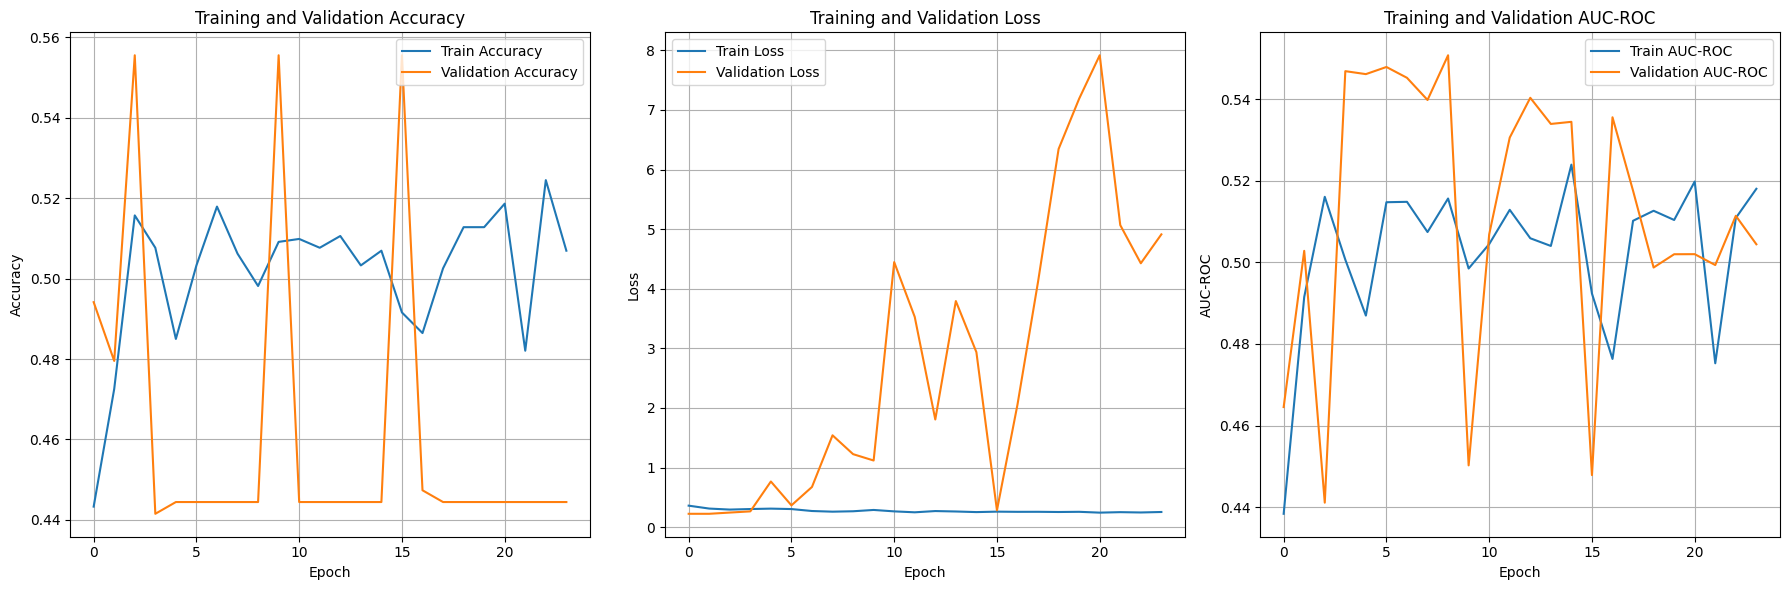


Code execution complete. Analyze the plots to understand model performance and guide further tuning.


In [48]:
# Visualizing the training progress helps diagnose overfitting, underfitting, and convergence.
print("\nGenerating training history plots...")

plt.figure(figsize=(18, 6))

# Plot Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot AUC-ROC
plt.subplot(1, 3, 3)
plt.plot(history.history['auc_roc'], label='Train AUC-ROC')
plt.plot(history.history['val_auc_roc'], label='Validation AUC-ROC')
plt.title('Training and Validation AUC-ROC')
plt.xlabel('Epoch')
plt.ylabel('AUC-ROC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nCode execution complete. Analyze the plots to understand model performance and guide further tuning.")

## Load test image and preprocess it 

In [49]:
sample_submission_path = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/sample_submission_(2)_(3).csv'
test_img_dir = '/Users/sandhyajeyaraj/Personal-Work/Machine-learning-projects/Fake vs Real Image Detection/dataset/test' # Directory for test images
IMG_SIZE = (160, 160) # MUST match the IMG_SIZE used during training

# Path to your best trained model
model_path = 'best_custom_fake_real_model.h5'


# --- 2. Load Test DataFrame ---
try:
    test_df = pd.read_csv(csv_test_path)
    print(f"Loaded test_df with {len(test_df)} entries.")
except FileNotFoundError as e:
    print(f"Error loading test CSV: {e}. Please check the path: {csv_test_path}")
    exit()

# --- 3. Prepare Test Image Paths ---
def get_test_image_path(file_id):
    """Constructs the full path for a test image."""
    return os.path.join(test_img_dir, f"{file_id}.jpg")

test_df['img_path'] = test_df['file_id'].apply(get_test_image_path)


# --- 4. Load Test Images ---
def load_test_images(df_to_load, img_size=IMG_SIZE):
    """Loads, preprocesses, and returns test images and their IDs."""
    images = []
    ids = []
    missing_images_count = 0
    for _, row in df_to_load.iterrows():
        img_path = row['img_path']
        img = cv2.imread(img_path)
        if img is not None:
            # IMPORTANT: Apply the SAME preprocessing as during training
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
            img = cv2.resize(img, img_size)            # Resize to training size
            img = img / 255.0                          # Normalize pixel values
            images.append(img)
            ids.append(row['file_id'])
        else:
            missing_images_count += 1
            # print(f"Warning: Test image not found or corrupted: {row['img_path']}") # Uncomment for detailed warnings
    if missing_images_count > 0:
        print(f"Warning: {missing_images_count} test images were not found or could not be loaded.")
    
    # Handle case where no images are loaded
    if not images:
        print("Error: No test images were loaded. Please check your test image directory and paths.")
        return np.array([]), []
        
    return np.array(images), ids

print("Loading test images...")
X_test, test_ids = load_test_images(test_df)
print(f"Loaded {X_test.shape[0]} test images.")

Loaded test_df with 332 entries.
Loading test images...
Loaded 332 test images.


## Predict the results

In [50]:
# It's crucial to load the model with custom_objects if your model used them during training.
# BinaryFocalCrossentropy and AdamW are custom objects from tensorflow_addons.
print(f"Loading the best model from: {model_path}")
try:
    # Define custom objects required by your model
    custom_objects = {
        "BinaryFocalCrossentropy": BinaryFocalCrossentropy,
        "AdamW": AdamW
    }
    best_model = load_model(model_path, custom_objects=custom_objects)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model {model_path}: {e}")
    print("Please ensure 'best_custom_fake_real_model.h5' exists and tensorflow_addons is installed.")
    exit()


# --- 6. Make Predictions ---
# Ensure X_test is not empty before predicting
if X_test.shape[0] > 0:
    print("Making predictions on test images...")
    pred_probs = best_model.predict(X_test, verbose=1) # verbose=1 to see prediction progress
    # Convert probabilities to class labels (0 or 1)
    pred_labels = (pred_probs > 0.5).astype(int).flatten()
    print("Predictions completed.")
else:
    print("No test images to predict. Skipping prediction phase.")
    pred_labels = np.array([])
    test_ids = []

Loading the best model from: best_custom_fake_real_model.h5
Model loaded successfully.
Making predictions on test images...
11/11 [==============================] - 11s 979ms/step
Predictions completed.


## prepare submission file

In [ ]:
submission = pd.DataFrame({
    'file_id': test_ids,
    'label': pred_labels
})

# --- 8. Ensure Order and Handle Missing Entries (Crucial for Competitions) ---
# Load the sample submission to get the required order of file_ids
try:
    sample_sub = pd.read_csv(sample_submission_path)
    print(f"Loaded sample_submission with {len(sample_sub)} entries.")
    
    # Merge your predictions with the sample submission to ensure correct order and fill missing IDs
    # Use how='left' to keep all file_ids from sample_sub
    submission = sample_sub[['file_id']].merge(submission, on='file_id', how='left')

    # Fill any file_ids from the sample_sub that were NOT predicted (e.g., if their image was missing)
    # with a default value (e.g., 0 or the majority class if known).
    # Using 0 as default here.
    initial_missing_preds = submission['label'].isnull().sum()
    if initial_missing_preds > 0:
        print(f"Warning: {initial_missing_preds} predictions were missing and filled with default value (0).")
    submission['label'] = submission['label'].fillna(0).astype(int)

except FileNotFoundError as e:
    print(f"Error loading sample_submission: {e}. Skipping merge with sample submission.")
    print("The 'submission.csv' might not have the correct order or all required file_ids.")


# --- 9. Save Submission File ---
submission_output_path = 'submission.csv'
submission.to_csv(submission_output_path, index=False)
print(f"Submission file saved as {submission_output_path}")
print(f"Submission file head:\n{submission.head()}")
print(f"Submission file value counts for 'label':\n{submission['label'].value_counts()}")

Submission file saved as submission.csv
